In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Cleaning & Feature Engineering

In [3]:
df = pd.read_csv("orders.csv", na_values=["Not Available", "unknown"])
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df["discount"] = df["list_price"] * (df["discount_percent"] / 100)
df["sale_price"] = df["list_price"] - df["discount"]
df["sales"] = df["sale_price"] * df["quantity"]
df["profit"] = (df["sale_price"] - df["cost_price"]) * df["quantity"]

df["order_date"] = pd.to_datetime(df["order_date"])


## Monthly Sales Trend

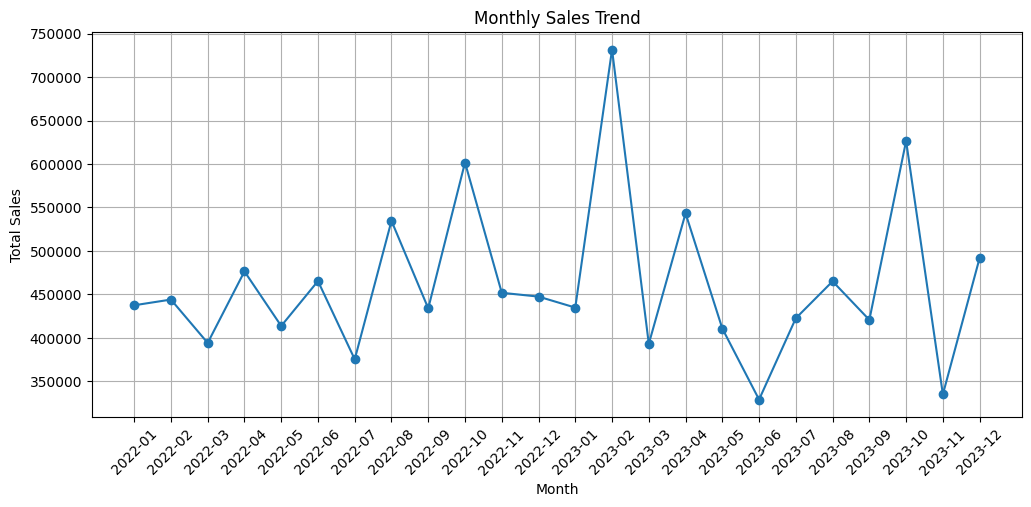

In [4]:
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum().reset_index()
monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["order_date"], monthly_sales["sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Month-over-Month Growth %

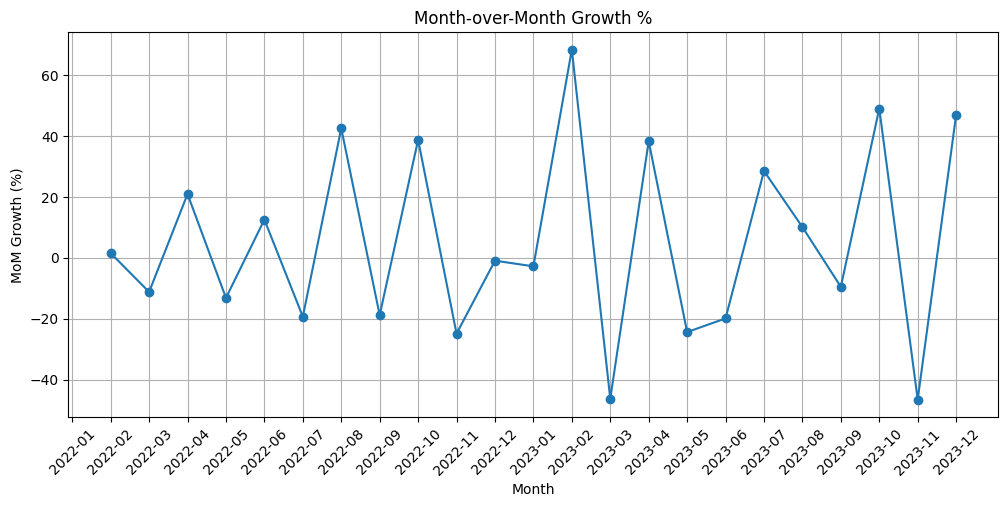

In [5]:
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum().reset_index()
monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

monthly_sales["prev_sales"] = monthly_sales["sales"].shift(1)
monthly_sales["mom_growth_percent"] = ((monthly_sales["sales"] - monthly_sales["prev_sales"]) / monthly_sales["prev_sales"]) * 100

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["order_date"], monthly_sales["mom_growth_percent"], marker="o")
plt.title("Month-over-Month Growth %")
plt.xlabel("Month")
plt.ylabel("MoM Growth (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Category Contribution %

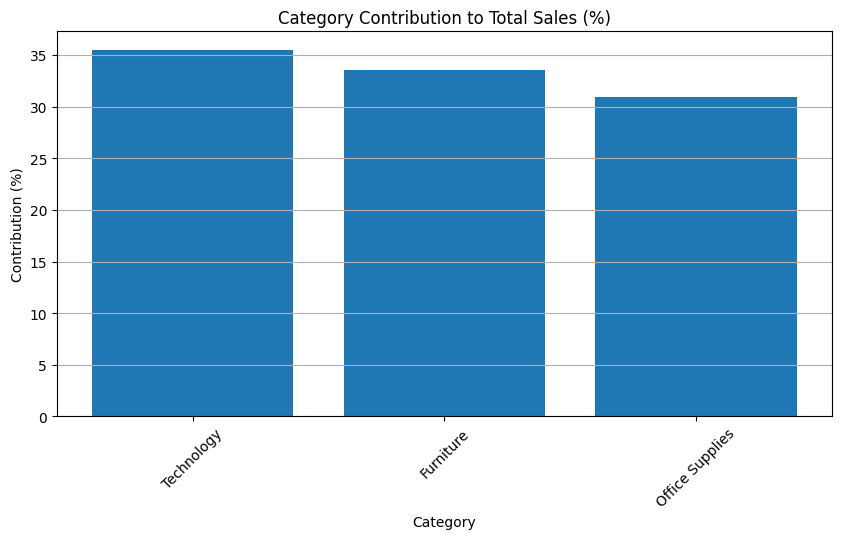

In [6]:
category_sales = df.groupby("category")["sales"].sum().reset_index()
total_sales = category_sales["sales"].sum()

category_sales["contribution_percent"] = (category_sales["sales"] / total_sales) * 100
category_sales = category_sales.sort_values("contribution_percent", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(category_sales["category"], category_sales["contribution_percent"])
plt.title("Category Contribution to Total Sales (%)")
plt.xlabel("Category")
plt.ylabel("Contribution (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


## Top 10 Products by Revenue

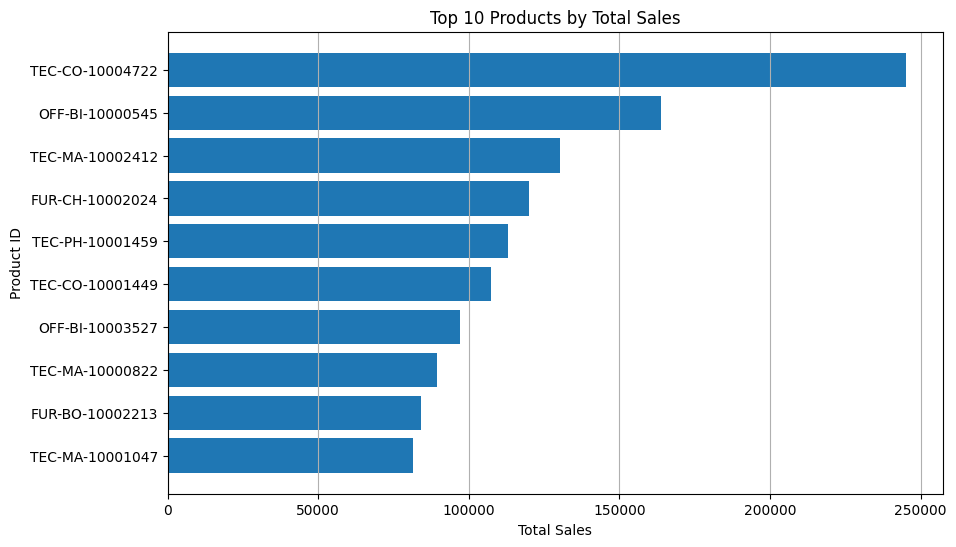

In [7]:
top_products = df.groupby("product_id")["sales"].sum().reset_index()
top_products = top_products.sort_values("sales", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_products["product_id"], top_products["sales"])
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product ID")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

## Region-wise YoY Growth %

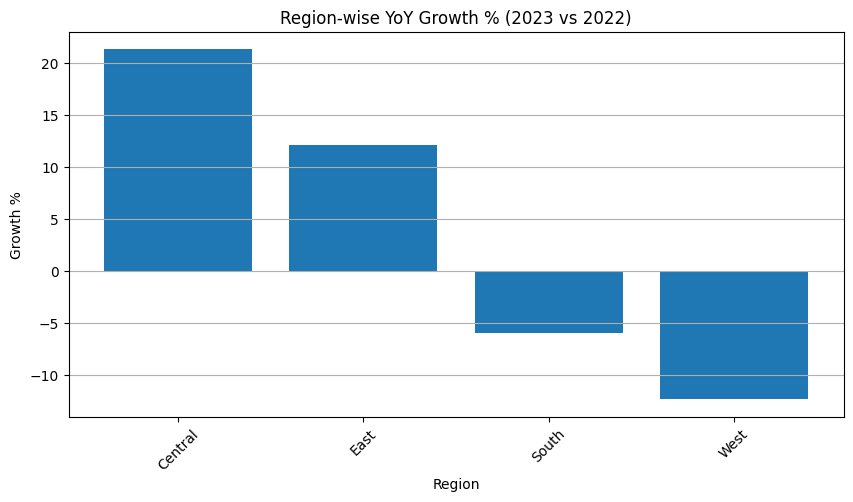

In [8]:
df["year"] = df["order_date"].dt.year

region_year_sales = df.groupby(["region", "year"])["sales"].sum().reset_index()

sales_2022 = region_year_sales[region_year_sales["year"] == 2022].set_index("region")["sales"]
sales_2023 = region_year_sales[region_year_sales["year"] == 2023].set_index("region")["sales"]

yoy_df = pd.DataFrame({
    "sales_2022": sales_2022,
    "sales_2023": sales_2023
}).fillna(0)

yoy_df["growth_percent"] = ((yoy_df["sales_2023"] - yoy_df["sales_2022"]) / yoy_df["sales_2022"]) * 100
yoy_df = yoy_df.replace([float("inf"), -float("inf")], 0)

yoy_df = yoy_df.sort_values("growth_percent", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(yoy_df.index, yoy_df["growth_percent"])
plt.title("Region-wise YoY Growth % (2023 vs 2022)")
plt.xlabel("Region")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


## Profit by Sub-Category (Top 10 + Bottom 10)

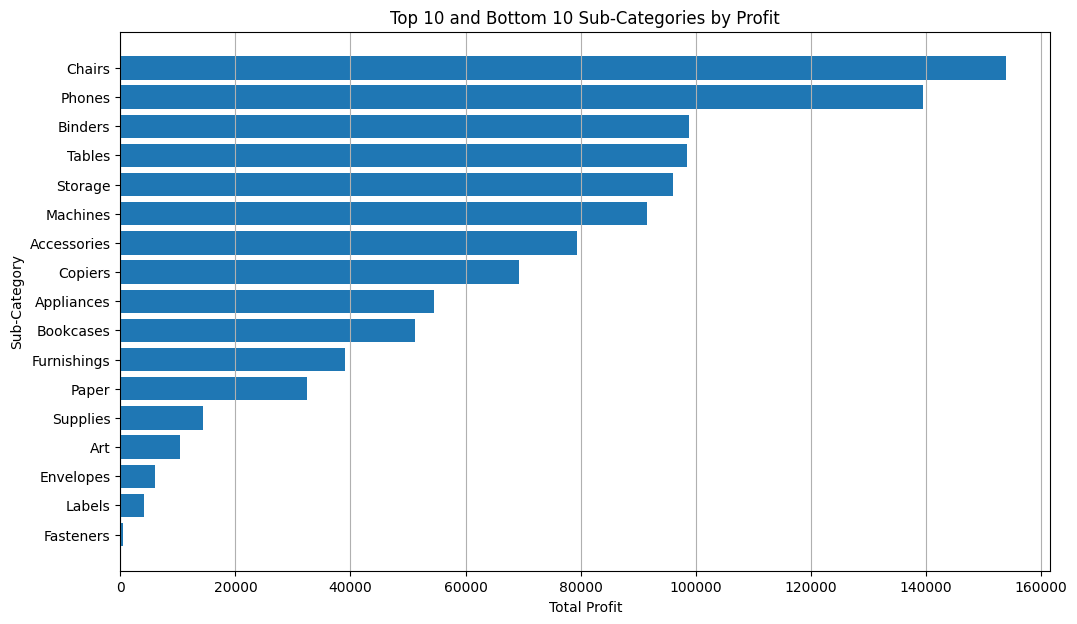

In [9]:
subcat_profit = df.groupby("sub_category")["profit"].sum().reset_index()

top10 = subcat_profit.sort_values("profit", ascending=False).head(10)
bottom10 = subcat_profit.sort_values("profit", ascending=True).head(10)

combined = pd.concat([top10, bottom10]).sort_values("profit", ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(combined["sub_category"], combined["profit"])
plt.title("Top 10 and Bottom 10 Sub-Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.grid(axis="x")
plt.show()
